In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
import joblib

In [38]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.head())
print(df.info())
print(df.describe())
cols = df.columns
print('Unique values in each column')
for col in cols:
    print(f"{col}: {df[col].unique()}")

   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [39]:
df['TotalCharges'] = df['TotalCharges'].replace(' ', np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')
print(df.isnull().sum())
df['TotalCharges'] = df['TotalCharges'].fillna(df['TotalCharges'].mean())
print(df.isnull().sum())

customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [40]:
# EDA (brief)
print(df['Churn'].value_counts(normalize=True))

# distribution of numeric features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(df[num_cols].describe())


No     0.73463
Yes    0.26537
Name: Churn, dtype: float64
            tenure  MonthlyCharges  TotalCharges
count  7043.000000     7043.000000   7043.000000
mean     32.371149       64.761692   2283.300441
std      24.559481       30.090047   2265.000258
min       0.000000       18.250000     18.800000
25%       9.000000       35.500000    402.225000
50%      29.000000       70.350000   1400.550000
75%      55.000000       89.850000   3786.600000
max      72.000000      118.750000   8684.800000


In [41]:
df = df.drop(columns=['customerID'])

# encoding target
df['Churn'] = df['Churn'].map({'Yes':1, 'No':0})

cat_cols = list(df.select_dtypes(include='object').columns)
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
print(cat_cols)
print(num_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
['tenure', 'MonthlyCharges', 'TotalCharges']


In [43]:
print(df[['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','MultipleLines']])

     OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV  \
0                No          Yes               No          No          No   
1               Yes           No              Yes          No          No   
2               Yes          Yes               No          No          No   
3               Yes           No              Yes         Yes          No   
4                No           No               No          No          No   
...             ...          ...              ...         ...         ...   
7038            Yes           No              Yes         Yes         Yes   
7039             No          Yes              Yes          No         Yes   
7040            Yes           No               No          No          No   
7041             No           No               No          No          No   
7042            Yes           No              Yes         Yes         Yes   

     StreamingMovies     MultipleLines  
0                 No  No phone ser

In [44]:
# Many categorical columns have values like 'No internet service' or 'No phone service' which
# are conceptually the same as 'No' for that feature. So replacing them.
replace_cols = ['OnlineSecurity','OnlineBackup','DeviceProtection','TechSupport','StreamingTV','StreamingMovies','MultipleLines']
for c in replace_cols:
    df[c] = df[c].replace({'No internet service':'No','No phone service':'No'})

# Feature Selectio
X = df[['tenure', 'MonthlyCharges', 'InternetService', 'Contract', 'PaymentMethod', 'SeniorCitizen']]
y = df['Churn']

numeric_cols = ['tenure', 'MonthlyCharges']
categorical_cols = ['InternetService', 'Contract', 'PaymentMethod', 'SeniorCitizen']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [46]:
preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numeric_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
])

models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced'),
    'SVM': SVC(probability=True, random_state=42),
    'KNN': KNeighborsClassifier()
}

results = {}

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)
    y_proba = pipeline.predict_proba(X_test)[:, 1]

    results[name] = {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba)
    }

pd.DataFrame(results).T

,accuracy,precision,recall,f1,roc_auc
LogisticRegression,0.792761,0.633987,0.518717,0.570588,0.834085
RandomForest,0.758694,0.554140,0.465241,0.505814,0.798821
SVM,0.795600,0.645270,0.510695,0.570149,0.796736
KNN,0.779276,0.602606,0.494652,0.543319,0.799632


Best params: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.50      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409

ROC AUC: 0.8404582913534321


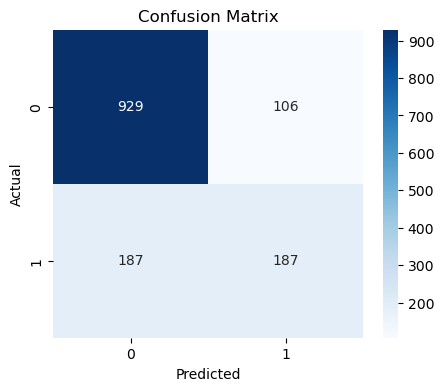

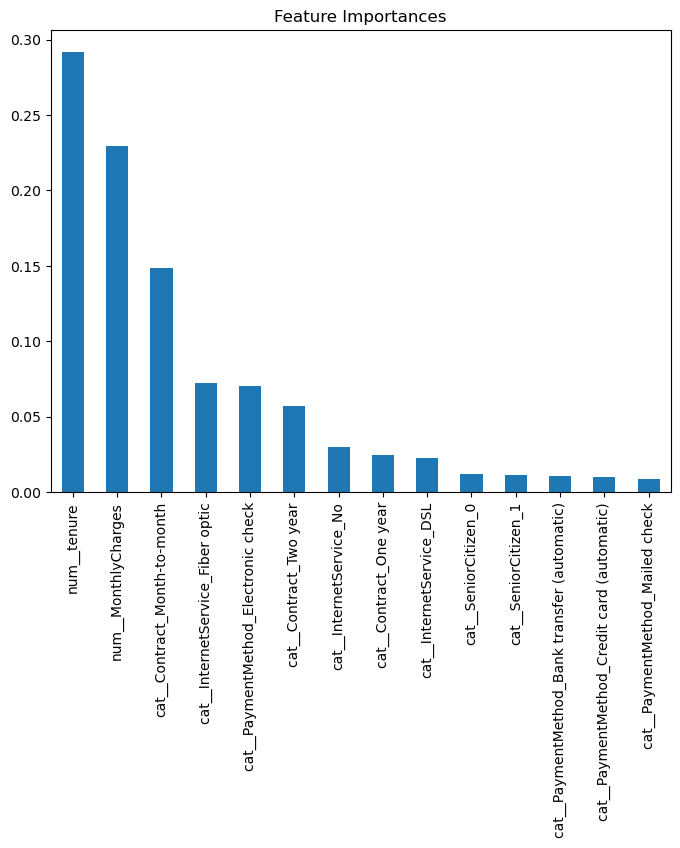

In [ ]:
rf = RandomForestClassifier(random_state=42)

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10]
}

cv = GridSearchCV(pipeline, param_grid, cv=3, scoring='roc_auc', n_jobs=-1)
cv.fit(X_train, y_train)

best_pipeline = cv.best_estimator_
print("Best params:", cv.best_params_)

y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature importances
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    fi = pd.Series(best_pipeline.named_steps['classifier'].feature_importances_,
                   index=feature_names).sort_values(ascending=False).head(20)
    plt.figure(figsize=(8,6))
    fi.plot(kind='bar')
    plt.title('Feature Importances')
    plt.show()

Best parameters: {'classifier__max_depth': 10, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 100}
              precision    recall  f1-score   support

           0       0.89      0.76      0.82      1035
           1       0.52      0.74      0.61       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.72      1409
weighted avg       0.79      0.75      0.76      1409

ROC AUC: 0.8393099795913095


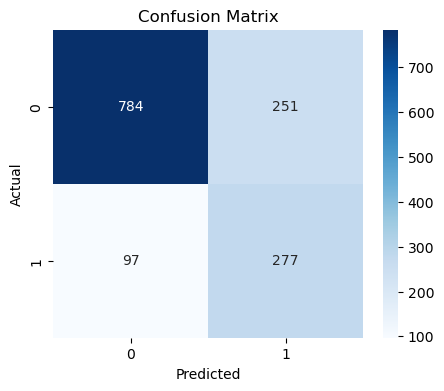

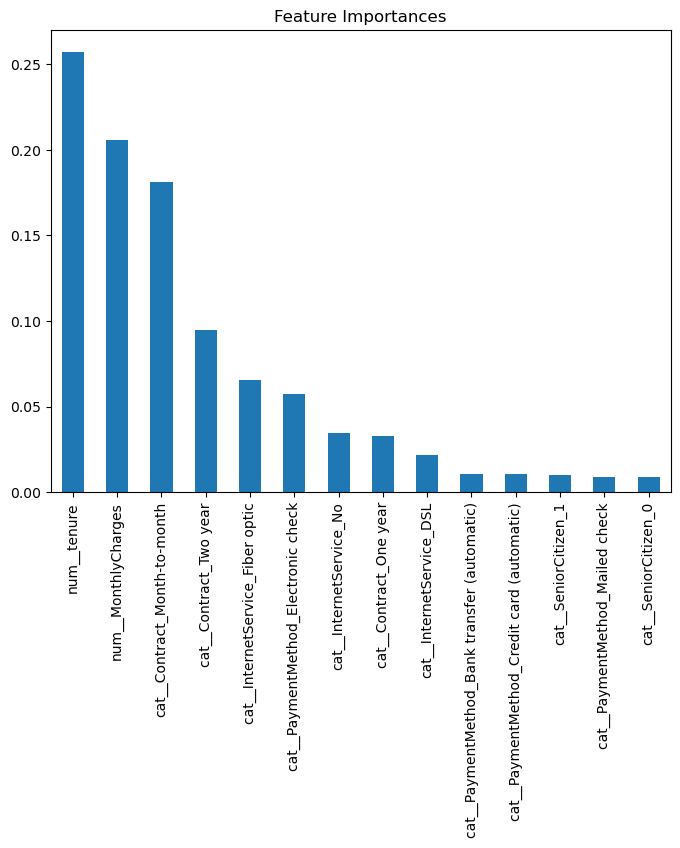

['model_pipeline.joblib']

In [ ]:
rf = RandomForestClassifier(random_state=42, class_weight='balanced')  # handle imbalance

pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', rf)
])

param_grid = {
    'classifier__n_estimators': [100, 200, 300],
    'classifier__max_depth': [None, 10, 20, 30],
    'classifier__min_samples_split': [2, 5, 10]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV with StratifiedKFold
cv = GridSearchCV(pipeline, param_grid, cv=skf, scoring='roc_auc', n_jobs=-1)
cv.fit(X_train, y_train)

best_pipeline = cv.best_estimator_
print("Best parameters:", cv.best_params_)

# Evaluating on test set
y_pred = best_pipeline.predict(X_test)
y_proba = best_pipeline.predict_proba(X_test)[:,1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

# Feature importances
if hasattr(best_pipeline.named_steps['classifier'], 'feature_importances_'):
    feature_names = best_pipeline.named_steps['preprocessor'].get_feature_names_out()
    fi = pd.Series(best_pipeline.named_steps['classifier'].feature_importances_,
                   index=feature_names).sort_values(ascending=False).head(20)
    plt.figure(figsize=(8,6))
    fi.plot(kind='bar')
    plt.title('Feature Importances')
    plt.show()

# Saving full pipeline for Streamlit app
joblib.dump(best_pipeline, 'model_pipeline.joblib')

Best KNN parameters: {'classifier__metric': 'manhattan', 'classifier__n_neighbors': 11, 'classifier__weights': 'uniform'}
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.63      0.47      0.54       374

    accuracy                           0.79      1409
   macro avg       0.73      0.69      0.70      1409
weighted avg       0.77      0.79      0.78      1409

ROC AUC: 0.8232039060683563


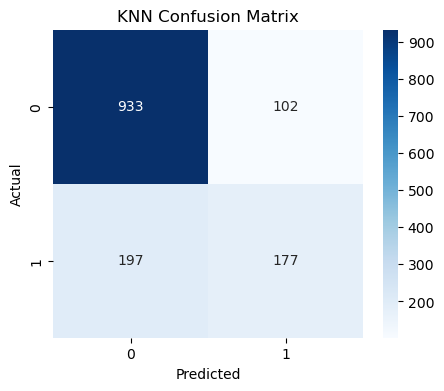

In [ ]:
knn = KNeighborsClassifier()

pipeline_knn = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', knn)
])

# GridSearchCV with StratifiedKFold
param_grid_knn = {
    'classifier__n_neighbors': [3, 5, 7, 9, 11],
    'classifier__weights': ['uniform', 'distance'],
    'classifier__metric': ['euclidean', 'manhattan']
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_knn = GridSearchCV(pipeline_knn, param_grid_knn, cv=skf, scoring='roc_auc', n_jobs=-1)

cv_knn.fit(X_train, y_train)

best_knn_pipeline = cv_knn.best_estimator_
print("Best KNN parameters:", cv_knn.best_params_)

# Evaluation on test set
y_pred = best_knn_pipeline.predict(X_test)
y_proba = best_knn_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('KNN Confusion Matrix')
plt.show()

In [ ]:
# pip install langchain_google_genai

In [ ]:
# for col in selected_cols:
#     print(f"{col}: {df[col].unique()}")

In [ ]:
# print(X_test[:10])
# print("----------------------")
# print(y_test[:10])